In [1]:
import os
import sys

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# The notebook lives in analysis/, but is often run from the repo root.
HERE = os.path.abspath("analysis" if os.path.isdir("analysis") else ".")
sys.path.insert(0, HERE)

from training_tables import (
    GOLD_STAGES,
    load_gold,
    table_learning,
    table_learning_relative,
    table_level_change_gold,
    dose_response,
)

pd.set_option("display.width", 120)
[name for name, _ in GOLD_STAGES]

['step480k', 'step1020k', 'step1840k', 'stage2-ing1', 'stage2-ing2']

In [2]:
TJ, LP, qids = load_gold()
TJ.shape, LP.shape, len(qids)

996 examples x 5 checkpoints; log P(gold)/token -7.680 -> -7.600 -> -7.499 -> -7.381 -> -7.344


((5, 996, 256), (5, 996), 996)

In [3]:
flips, wil = table_learning(TJ, LP)
print(flips.to_string(index=False))
print(f"\nlearned below unlearned on {wil['heads_lower']}/{wil['n_heads']} heads "
      f"(W={wil['W']:.0f}, p={wil['p']:.2e})")

transition      group     n     shift
      0->1    learned 100.0 -0.006746
      0->1  unlearned 100.0 -0.001360
      0->1  unchanged 796.0 -0.006117
      1->2    learned 100.0 -0.000623
      1->2  unlearned 100.0  0.004671
      1->2  unchanged 796.0  0.004007
      2->3    learned 100.0 -0.002072
      2->3  unlearned 100.0  0.006771
      2->3  unchanged 796.0  0.005518
      3->4    learned 100.0 -0.005173
      3->4  unlearned 100.0 -0.003482
      3->4  unchanged 796.0 -0.003889
    pooled    learned   NaN -0.003654
    pooled  unlearned   NaN  0.001650
    pooled  unchanged   NaN -0.000120
    pooled difference   NaN -0.005304

learned below unlearned on 180/256 heads (W=7755, p=2.29e-13)


In [4]:
pooled = flips[flips.transition == "pooled"].set_index("group")["shift"]
per_tr = flips[flips.transition != "pooled"].pivot(index="transition", columns="group", values="shift")

claims = pd.DataFrame([
    dict(claim="1. learned examples settle (entropy falls)",
         observed=pooled["learned"],
         predicted="< 0",
         holds=pooled["learned"] < 0,
         detail=f"{int((per_tr['learned'] < 0).sum())}/{len(per_tr)} transitions negative; "
                f"{wil['heads_lower']}/{wil['n_heads']} heads, p={wil['p']:.1e}"),
    dict(claim="2. unlearned examples destabilise (entropy rises)",
         observed=pooled["unlearned"],
         predicted="> 0, and > learned",
         holds=pooled["unlearned"] > 0,
         detail=f"{int((per_tr['unlearned'] > 0).sum())}/{len(per_tr)} transitions positive"),
    dict(claim="3. control does not move (no global drift)",
         observed=pooled["unchanged"],
         predicted="~ 0",
         holds=abs(pooled["unchanged"]) < abs(pooled["learned"]),
         detail=f"|control| vs |learned| = {abs(pooled['unchanged']):.4f} vs {abs(pooled['learned']):.4f}"),
])
claims.style.format({"observed": "{:+.4f}"}) if hasattr(claims, "style") else claims

,claim,observed,predicted,holds,detail
0,1. learned examples settle (entropy falls),-0.0037,< 0,True,"4/4 transitions negative; 180/256 heads, p=2.3e-13"
1,2. unlearned examples destabilise (entropy rises),+0.0017,"> 0, and > learned",True,2/4 transitions positive
2,3. control does not move (no global drift),-0.0001,~ 0,True,|control| vs |learned| = 0.0001 vs 0.0037


In [5]:
# Per-transition detail behind the summary above: the sign pattern matters more than any
# single pooled magnitude, since one transition can carry a pooled mean on its own.
per_tr[["learned", "unlearned", "unchanged"]]

group,learned,unlearned,unchanged
transition,,,
0->1,-0.006746,-0.001360,-0.006117
1->2,-0.000623,0.004671,0.004007
2->3,-0.002072,0.006771,0.005518
3->4,-0.005173,-0.003482,-0.003889


In [ ]:
_CACHE = {}


def load_field(field):
    if field not in _CACHE:
        per = []
        for _, rev in GOLD_STAGES:
            with np.load(os.path.join(HERE, "gold_scores", f"{rev}.npz")) as z:
                tj_all, lp_all, qid_all = z["tj"], z[field], z["qids"]
            per.append({q: (tj_all[i], lp_all[i]) for i, q in enumerate(qid_all)})
        shared = sorted(set.intersection(*(set(p) for p in per)))
        _CACHE[field] = (np.stack([np.stack([p[q][0] for q in shared]) for p in per]),
                         np.stack([np.array([p[q][1] for q in shared]) for p in per]))
    return _CACHE[field]


def sweep(field="logp_mean", quantiles=(0.05, 0.10, 0.15, 0.20, 0.25, 0.30),
          transition_sets=((0, 1, 2, 3), (1, 2, 3))):
    # Pooled group shifts and the head-level test across grouping choices.
    tj, lp = load_field(field)
    rows = []
    for q in quantiles:
        for tr in transition_sets:
            g = {"learned": [], "unlearned": [], "unchanged": []}
            for i in tr:
                d_lp, d_tj = lp[i + 1] - lp[i], tj[i + 1] - tj[i]
                lo, hi = np.quantile(d_lp, q), np.quantile(d_lp, 1 - q)
                g["learned"].append(np.nanmean(d_tj[d_lp >= hi]))
                g["unlearned"].append(np.nanmean(d_tj[d_lp <= lo]))
                g["unchanged"].append(np.nanmean(d_tj[(d_lp > lo) & (d_lp < hi)]))
            a = np.nanmean([np.nanmean((tj[i+1] - tj[i])[(lp[i+1] - lp[i]) >= np.quantile(lp[i+1] - lp[i], 1 - q)], axis=0) for i in tr], axis=0)
            b = np.nanmean([np.nanmean((tj[i+1] - tj[i])[(lp[i+1] - lp[i]) <= np.quantile(lp[i+1] - lp[i], q)], axis=0) for i in tr], axis=0)
            ok = np.isfinite(a) & np.isfinite(b)
            _, p = wilcoxon(a[ok], b[ok])
            rows.append(dict(field=field, q=q, n_transitions=len(tr),
                             learned=np.mean(g["learned"]), unlearned=np.mean(g["unlearned"]),
                             unchanged=np.mean(g["unchanged"]),
                             heads=f"{int((a[ok] < b[ok]).sum())}/{int(ok.sum())}", p=p))
    return pd.DataFrame(rows)


grid = pd.concat([sweep("logp_mean"), sweep("logp_sum")], ignore_index=True)
grid.round(5)

,field,q,n_transitions,learned,unlearned,unchanged,heads,p
0,logp_mean,0.05,4,-0.00400,0.00139,-0.00018,168/256,0.0
1,logp_mean,0.05,3,-0.00292,0.00274,0.00168,164/256,0.0
2,logp_mean,0.10,4,-0.00365,0.00165,-0.00012,180/256,0.0
3,logp_mean,0.10,3,-0.00262,0.00265,0.00188,176/256,0.0
4,logp_mean,0.15,4,-0.00351,0.00149,0.00001,179/256,0.0
5,logp_mean,0.15,3,-0.00218,0.00307,0.00196,183/256,0.0
6,logp_mean,0.20,4,-0.00261,0.00094,0.00006,172/256,0.0
7,logp_mean,0.20,3,-0.00122,0.00255,0.00207,171/256,0.0
8,logp_mean,0.25,4,-0.00225,0.00080,0.00013,171/256,0.0
9,logp_mean,0.25,3,-0.00089,0.00240,0.00225,168/256,0.0


In [7]:
# Which conclusions hold everywhere in the grid?
print(f"learned < 0            in {int((grid.learned < 0).sum())}/{len(grid)} settings")
print(f"unlearned > 0          in {int((grid.unlearned > 0).sum())}/{len(grid)} settings")
print(f"learned < unlearned    in {int((grid.learned < grid.unlearned).sum())}/{len(grid)} settings")
print(f"|control| < |learned|  in {int((grid.unchanged.abs() < grid.learned.abs()).sum())}/{len(grid)} settings")
print(f"p < 1e-5               in {int((grid.p < 1e-5).sum())}/{len(grid)} settings"
      f"  (range {grid.p.min():.1e} to {grid.p.max():.1e})")

learned < 0            in 24/24 settings
unlearned > 0          in 24/24 settings
learned < unlearned    in 24/24 settings
|control| < |learned|  in 17/24 settings
p < 1e-5               in 24/24 settings  (range 7.2e-17 to 3.6e-06)


In [8]:
print("dose-response (all examples, relative % change vs. change in log P(gold)):")
print(dose_response(TJ, LP).to_string(index=False))

print("\nlevel vs. change, on the worst-scored half at the earlier checkpoint:")
print(table_level_change_gold(TJ, LP).to_string(index=False))

dose-response (all examples, relative % change vs. change in log P(gold)):
transition   n       rho        p  mean_rel_pct
      0->1 996 -0.058612 0.064453     -0.406622
      1->2 996 -0.115307 0.000266      1.267965
      2->3 996 -0.154164 0.000001      1.216272
      3->4 996 -0.087579 0.005678     -0.793640

level vs. change, on the worst-scored half at the earlier checkpoint:
transition   n       rho            p  mean_dTJ
      0->1 498 -0.108524 8.309466e-02 -0.005322
      1->2 498 -0.176635 4.587547e-03  0.003114
      2->3 498 -0.161922 9.452962e-03  0.006040
      3->4 498  0.332929 4.835184e-08 -0.004637


In [9]:
rel = table_learning_relative(TJ, LP)
print(rel.to_string(index=False))

transition      group     n   rel_pct
      0->1    learned 100.0 -0.496748
      0->1  unlearned 100.0  0.475365
      0->1  unchanged 796.0 -0.506102
      1->2    learned 100.0  0.510783
      1->2  unlearned 100.0  1.593158
      1->2  unchanged 796.0  1.322235
      2->3    learned 100.0 -0.087283
      2->3  unlearned 100.0  1.494268
      2->3  unchanged 796.0  1.345111
      3->4    learned 100.0 -1.043150
      3->4  unlearned 100.0 -0.721597
      3->4  unchanged 796.0 -0.771345
    pooled    learned   NaN -0.279099
    pooled  unlearned   NaN  0.710298
    pooled  unchanged   NaN  0.347475
    pooled difference   NaN -0.989398


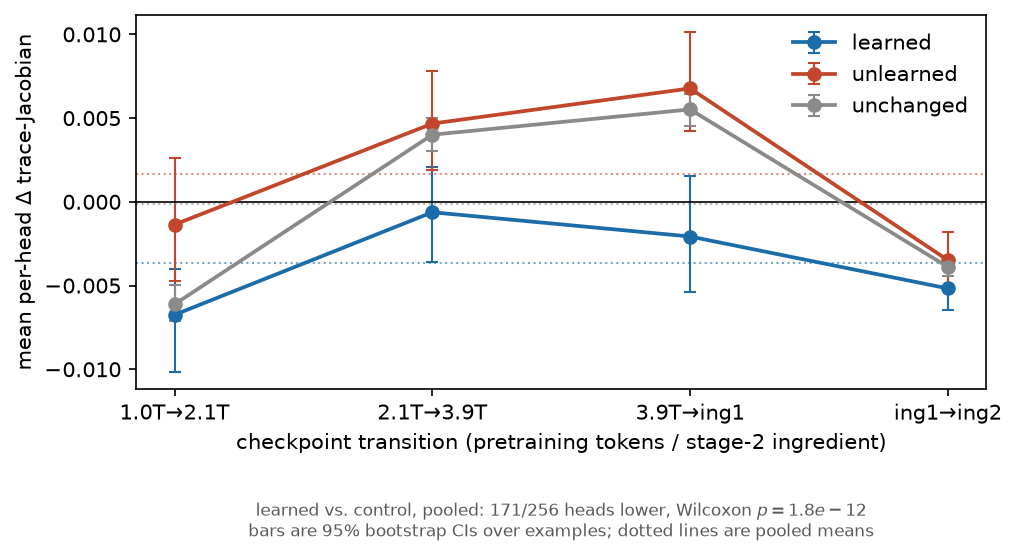

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

def handle(name, rev):
    if "stage2" in rev:
        return "ing" + rev.split("ingredient")[1][0]
    return f"{int(rev.split('tokens')[1].rstrip('B')) / 1000:.1f}T"

HANDLES = [handle(n, r) for n, r in GOLD_STAGES]
LABELS = [f"{HANDLES[i]}→{HANDLES[i+1]}" for i in range(len(HANDLES) - 1)]

rng = np.random.default_rng(0)
B, n_ex = 1000, TJ.shape[1]
ci = {g: np.zeros((len(LABELS), 2)) for g in ("learned", "unlearned", "unchanged")}
for i in range(len(LABELS)):
    draws = {g: [] for g in ci}
    for _ in range(B):
        s = rng.integers(0, n_ex, n_ex)
        d_lp, d_tj = (LP[i + 1] - LP[i])[s], (TJ[i + 1] - TJ[i])[s]
        lo, hi = np.quantile(d_lp, 0.1), np.quantile(d_lp, 0.9)
        draws["learned"].append(np.nanmean(d_tj[d_lp >= hi]))
        draws["unlearned"].append(np.nanmean(d_tj[d_lp <= lo]))
        draws["unchanged"].append(np.nanmean(d_tj[(d_lp > lo) & (d_lp < hi)]))
    for g in ci:
        ci[g][i] = np.percentile(draws[g], [2.5, 97.5])

# Pooled head-level test, reported for what it is: cross-head consistency.
def pooled_head_means(sel):
    return np.nanmean([np.nanmean((TJ[i + 1] - TJ[i])[sel(i)], axis=0)
                       for i in range(len(LABELS))], axis=0)
d = lambda i: LP[i + 1] - LP[i]
a = pooled_head_means(lambda i: d(i) >= np.quantile(d(i), 0.9))
b = pooled_head_means(lambda i: (d(i) > np.quantile(d(i), 0.1)) & (d(i) < np.quantile(d(i), 0.9)))
ok = np.isfinite(a) & np.isfinite(b)
_, p_heads = wilcoxon(a[ok], b[ok])

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"learned": "#1b6ca8", "unlearned": "#c1462b", "unchanged": "#8a8a8a"}
x = np.arange(len(per_tr))
for g, c in colors.items():
    y = per_tr[g].values
    ax.errorbar(x, y, yerr=[y - ci[g][:, 0], ci[g][:, 1] - y], fmt="o-", color=c,
                label=g, lw=1.8, ms=6, capsize=3, elinewidth=1)
    ax.axhline(pooled[g], color=c, ls=":", lw=1, alpha=0.6)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, LABELS)
ax.set_xlabel("checkpoint transition (pretraining tokens / stage-2 ingredient)")
ax.set_ylabel(r"mean per-head $\Delta$ trace-Jacobian")
ax.legend(frameon=False)
ax.annotate(
    f"learned vs. control, pooled: {int((a[ok] < b[ok]).sum())}/{int(ok.sum())} heads lower, "
    f"Wilcoxon $p={p_heads:.1e}$\n"
    f"bars are 95% bootstrap CIs over examples; dotted lines are pooled means",
    xy=(0.5, -0.30), xycoords="axes fraction", ha="center", va="top", fontsize=8, color="0.35")
fig.tight_layout()
plt.show()